In [37]:
import os, sys
import esutil
import healpy as hp
import numpy as np
# call required functions from modules 
sys.path.append('code_py3/')
from cmass_modules import io
from utils import matchCatalogsbyPosition, hpHEALPixelToRaDec, HealPixifyCatalogs, spatialcheck
from xd import mixing_color, XD_fitting_X, assignCMASSProb, doVisualization_1d
from run_DMASS_Y3 import priorCut_test
from sys_functions import *

In [71]:
from xdgmm import XDGMM as XDGMM_Holoien

def _FindOptimalN_with_err( N, Xdata, Xcov, pickleFileName = None, suffix = None):
    #from sklearn.mixture import GMM
    #data, _ = mixing_color(data, suffix = suffix)
    @pickle_results( pickleFileName )
    def compute_GMM( N, covariance_type='full', n_iter=10000):
        models = [None for n in N]
        for i in range(len(N)):
            sys.stdout.write("\r" + 'Finding optimal number of cluster : {:0.0f} % '\
                             .format(i * 1./len(N) * 100.))
            sys.stdout.flush()
            models[i] = GaussianMixture(n_components=N[i], max_iter=n_iter,
                            covariance_type=covariance_type)
            models[i].fit(Xdata, Xcov)
        return models
    
    models = compute_GMM(N)
    AIC = [m.aic(Xdata) for m in models]
    BIC = [m.bic(Xdata) for m in models]
    i_best = np.argmin(BIC)
    gmm_best = models[i_best]
    sys.stdout.write("\r" + 'Finding optimal number of cluster : {:0.0f} % '\
                     .format(100))
    print("\nbest fit converged:", gmm_best.converged_, end=' ')
    print(" n_components =  %i" % N[i_best])
    return N[i_best], AIC, BIC

def XDnew_fitting_X( X = None, Xcov=None, 
        FileName = None, 
        #init_params = None, 
        #suffix='', 
        #mag = ['MAG_MODEL', 'MAG_DETMODEL'],
        #err = [ 'MAGERR_MODEL','MAGERR_DETMODEL'],
        #filter = ['G', 'R', 'I'],
        n_cl = None, n_iter = 500, tol=1E-5, method='Bovy', verbose=False ):    

    try: 
        xdgmm_obj = XDGMM_Holoien(filename=FileName) 
        print ('Using precomputed results from ', FileName)
        return xdgmm_obj
    except FileNotFoundError: pass
    
    if X is None:
        # calling pre-computed model
        xdgmm_obj = XDGMM_Holoien(filename=FileName) 
        print ('Using precomputed results from ', FileName)
        return xdgmm_obj

    else: 
        if n_cl == None : 
            param_range=np.arange(2, 50, 2)
            optimal_n_comp,_,_= _FindOptimalN_with_err( param_range, X, Xcov, 
            pickleFileName = FileName+'.n_cluster' , suffix = '')
            
            #xdgmm_test = XDGMM_Holoien( n_iter=n_iter, tol=tol, method=method )
            ## Define the range of component numbers, and get ready to compute the BIC for each one:
            #param_range = np.arange(2, 50, 2)
            ## Loop over component numbers, fitting XDGMM model and computing the BIC:
            #bic, optimal_n_comp, lowest_bic = xdgmm_test.bic_test(X, Xcov, param_range)
            ##n_cl = optimal_n_comp[np.argmin(bic)]
        else: optimal_n_comp = n_cl

        #import time
        # fitting
        #initiated class
        xdgmm_obj = XDGMM_Holoien( n_components=optimal_n_comp, n_iter=n_iter, tol=tol, method=method )
        #xdgmm.n_components = optimal_n_comp
        print ('n_components=', optimal_n_comp)
        print ('fitting started. This will take for a while.')
#        t1 = time.time()
        xdgmm_obj = xdgmm_obj.fit(X, Xcov)
        #t2 = time.time()
        print ('fitting finished')
        
        #t3 = time.time()
        print ('saving xdgmm object to.. ', FileName)
        xdgmm_obj.save_model(FileName)
        print ('file saved')
        #print ('saving obj. time:', (t3-t2)%60,'s')
        
        #t4 = time.time()
        xdgmm_obj = XDGMM_Holoien(filename=FileName) 
        #print ('loading obj. time:', (t4-t3)%60,'s')
#        t2 = time.time()
#        print ('elapsed time:', (t2-t1)/60.0,'s')
        return xdgmm_obj

def keepGoodRegion(des, hpInd = False, balrog=None):
    import healpy as hp
    import fitsio
    # 25 is the faintest object detected by DES
    # objects larger than 25 considered as Noise
    
    path = '/fs/scratch/PCON0003/warner785/bwarner/'
    #LSSGoldmask = fitsio.read(path+'Y1LSSmask_v2_il22_seeil4.0_nside4096ring_redlimcut.fits')
    #LSSGoldmask = fitsio.read(path+'Y1LSSmask_v1_il22seeil4.04096ring_redlimcut.fits')
    LSSGoldmask = fitsio.read(path+'MASK_Y3LSSBAOSOF_22_3_v2p2.fits')
    ringhp = hp.nest2ring(4096, [LSSGoldmask['PIXEL']])
    #Y1LSSmask_v1_il22seeil4.04096ring_redlimcut.fits
    #frac_cut = LSSGoldmask['FRAC'] > 0.8
    #ind_good_ring = LSSGoldmask['PIXEL'][frac_cut]
    ind_good_ring = ringhp
    
    # healpixify the catalog.
    nside=4096
    # Convert silly ra/dec to silly HP angular coordinates.
    phi = des['RA'] * np.pi / 180.0
    theta = ( 90.0 - des['DEC'] ) * np.pi/180.0

    hpInd = hp.ang2pix(nside,theta,phi,nest=False)
    keep = np.in1d(hpInd, ind_good_ring)
    des = des[keep]
    if hpInd is True:
        return ind_good_ring
    else:
        return des
    
def doVisualization_1d( data=None, labels = None, 
ranges = None, name = None, weight = [None,None], 
color=['grey', 'tab:blue', 'tab:orange', 'tab:green'],
nbins=100, filename=None):


    if labels == None:
        print(" always label your axes! you must populate the 'labels' keyword with one entry for each dimension of the data.")
        stop
    else:
        ndim = len(labels)
    
    if ranges == None:
        # try to figure out the correct axis ranges.
        print("Using central 100% to set range.")
        ranges = []
        for i in range(ndim):
            ranges.append( np.percentile(data[-1][:,i],[0.,100.]) )

    
    fig,axes = plt.subplots(nrows=1, ncols= ndim, figsize= (4*ndim, 4) )
    #print weight[0], weight[1].size, data1[:,0].size 
    for i in range(ndim):
        xbins = np.linspace(ranges[i][0],ranges[i][1], nbins)
        for j in range(len(data)):    
            if j == 1:
                axes[i].hist(data[j][:,i],bins=xbins, label=name[j], weights=weight[j], alpha = 0.8, color =color[j], density=True, histtype='step')
            else:
                axes[i].hist(data[j][:,i],bins=xbins, label=name[j], weights=weight[j], alpha = 0.5, color =color[j], density=True)
            #axes[i].hist(data[:,i],bins=xbins, alpha=1.0,label=name[1], weights=weight[1], histtype='step', color='k', lw=1, density=True)
        axes[i].set_xlabel(labels[i], fontsize = 20)
        #axes[i].hist(data2[:,i],bins=xbins,normed=True,alpha=0.5,label='data2')
        axes[i].get_yaxis().set_visible(False)
        axes[i].tick_params(labelsize=15)
        axes[i].legend(loc='best',fontsize = 10)

    #filename = "figure/diagnostic_histograms_1d.pdf"
    #print("writing output plot to: "+filename)
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.05, hspace=0.5);
    if filename != None: fig.savefig(filename)
    #plt.close(fig)
    
def mixing_color_full(data, suffix = '', 
    mag = ['MAG_DETMODEL', 'MAG_DETMODEL'], 
    err = [ 'MAGERR_DETMODEL', 'MAGERR_DETMODEL'], 
    filter = ['G', 'R', 'I', 'Z'],
    full=False,
    no_zband = False  ):
    
    magtag = [ m+'_'+f+suffix for m in mag for f in filter ]
    errtag = [ e+'_'+f for e in err for f in filter ]
    if 'Z' in filter: del magtag[3], errtag[3]
    #del magtag[0], errtag[0]
    print(magtag)

    X = [ data[mt] for mt in magtag ]
    Xerr = [ data[mt] for mt in errtag ]
    #reddeningtag = 'XCORR_SFD98'

    X = np.vstack(X).T
    Xerr = np.vstack(Xerr).T
    # mixing matrix
    if full:          #g, r, i, z, g, r, i, z
        W = np.array([[1, 0, 0, 0, 0, 0, 0, 0], # g mag
                      [0, 1, 0, 0, 0, 0, 0, 0], # r mag
                    [0, 0, 1, 0, 0, 0, 0, 0],   # i mag
                    [0, 0, 0, 1, 0, 0, 0, 0],   # z mag
                    [0, 0, 0, 0, 1, -1, 0, 0],  # g-r
                    [0, 0, 0, 0, 1, 0, -1, 0],  # g-i
                    [0, 0, 0, 0, 1, 0, 0, -1],   # g-z
                    [0, 0, 0, 0, 0, 1, -1, 0],   # r-i
                    [0, 0, 0, 0, 0, 0, 1, -1],   # i-z
                    [0, 0, 0, 0, 0, 1, 0, -1]])  # r-z  
    else:
        W = np.array([[1, 0, 0, 0, 0, 0, 0], # g mag
                    [0, 1, 0, 0, 0, 0, 0],   # r mag
                    [0, 0, 1, 0, 0, 0, 0],   # i mag
                    [0, 0, 0, 1, -1, 0, 0],  # g-r
                    [0, 0, 0, 0, 1, -1, 0],   # r-i
                    [0, 0, 0, 0, 1, 0, -1]])  # r-z  

    #if 'Z' not in filter: W = W[:-1,:-1]
    X = np.dot(X, W.T)
    
    Xcov = np.zeros(Xerr.shape + Xerr.shape[-1:])
    Xcov[:, list(range(Xerr.shape[1])), list(range(Xerr.shape[1]))] = Xerr**2
    Xcov = np.tensordot(np.dot(Xcov, W.T), W, (-2, -1))
    
    return X, Xcov


In [3]:
# st82 region
outdir = '/fs/scratch/PCON0008/warner785/bwarner/'
gold_train = esutil.io.read(outdir+'gold_training.fits')
#gold_val = esutil.io.read(outdir+'gold_validation.fits')

# spt region
#gold_spt_region = fitsio.read('/fs/scratch/PCON0008/warner785/bwarner/gold_spt_region/gold_spt_FULL.fits')

#print(gold_train.dtype.names)

import fitsio
cmass = esutil.io.read('/fs/scratch/PCON0003/warner785/bwarner/cmass-dr12v4-S-Reid-full.dat.fits')
train_sample = esutil.io.read('/fs/scratch/PCON0003/warner785/bwarner/cmass-dr12v4-S-Reid-full.dat.fits')
#train_sample = esutil.io.read('/global/cscratch1/sd/bwarner/galaxy_DR11v1_CMASS_South-photoObj.fits.gz')
print('total num of train', train_sample.size)
print('\n--------------------------------\n applying DES veto mask to CMASS\n--------------------------------')   
train_sample = keepGoodRegion(train_sample)

#fitsio.write( output_dir+'/cmass_in_st82.fits', train_sample)

print('num of train_sample after des veto', train_sample.size)

total num of train 258884

--------------------------------
 applying DES veto mask to CMASS
--------------------------------
num of train_sample after des veto 61031


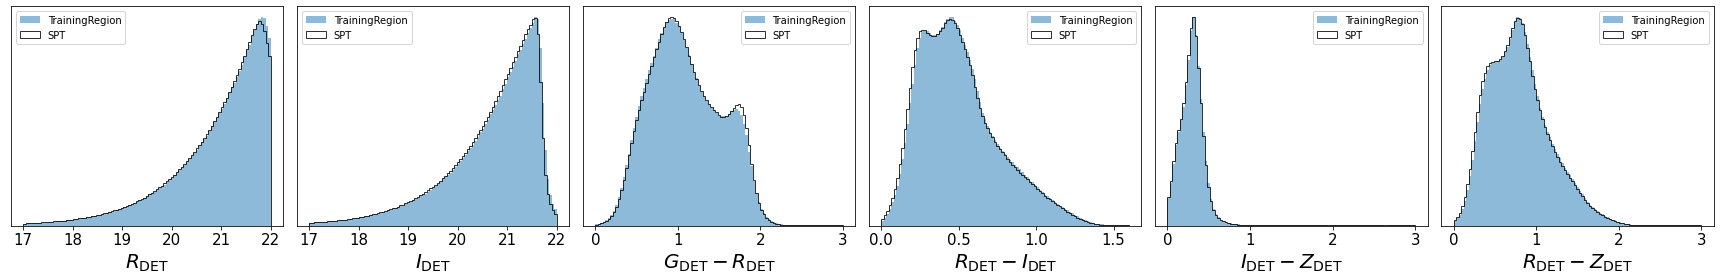

In [7]:
doVisualization_1d( data=[X_train, X_spt], 
                   labels = [r'${R_{\rm DET}}$', r'${I_{\rm DET}}$', r'$G_{\rm DET}-R_{\rm DET}$', r'$R_{\rm DET}-I_{\rm DET}$', r'$I_{\rm DET}-Z_{\rm DET}$', r'$R_{\rm DET}-Z_{\rm DET}$'], 
                   ranges = [(17,22),(17,22),(0,3),(0.0,1.6),(0,3),(0,3)], 
                   name = ['TrainingRegion', 'SPT'], 
                   weight = [None,None], 
                   color = ['tab:blue','black'],
                   nbins=100, filename = 'checkZ2.pdf')

In [4]:
# TRAINING REGION CMASS

mg1, mg2, _ = esutil.htm.HTM(10).match(train_sample['RA'], train_sample['DEC'], gold_train['RA'], \
                                         gold_train['DEC'],2./3600, maxmatch=1)
cmass_mask = np.zeros(gold_train.size, dtype=bool)
cmass_mask[mg2] = 1
clean_cmass_data_des_train, nocmass_train = gold_train[cmass_mask], gold_train[~cmass_mask]

print(nocmass_train.size)

print(('num of cmass in des side in training', clean_cmass_data_des_train.size, '({:0.0f}%)'.format(clean_cmass_data_des_train.size*1./cmass.size*100.)))

cmass_fraction_new = clean_cmass_data_des_train.size *1./gold_train.size
print(cmass_fraction_new)

2848436
('num of cmass in des side in training', 30125, '(12%)')
0.010465298459890202


In [72]:
mag = ['MAG_DETMODEL', 'MAG_DETMODEL']
err = [ 'MAGERR_DETMODEL', 'MAGERR_DETMODEL']
filter = ['G', 'R', 'I', 'Z']

X_gold, X_gold_cov = mixing_color_full(clean_cmass_data_des_train, 
                mag = mag, err=err, filter=filter, 
                no_zband = False )

['MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_Z']


In [73]:
n_iter_gold = 10000
# tolerance
tol = 1E-5

# Fitted parameters and covariance will be stored as a pickle
outdir = 'output/test/fitting/'
os.makedirs(outdir, exist_ok=True)
gold_xd_bovy_filename = outdir+'gold_zband_test.xdgmm'

#n_cl_gold,_,_= _FindOptimalN_with_err( np.arange(2, 50, 2), X_gold, None, 
#            pickleFileName = gold_xd_bovy_filename+'.n_cluster' , suffix = '')

In [ ]:
clf_gold = XDnew_fitting_X( X_gold, X_gold_cov, FileName = gold_xd_bovy_filename, 
                    n_cl = 10, n_iter = n_iter_gold, tol = tol, method='Bovy')

n_components= 10
fitting started. This will take for a while.


/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/sklearn/mixture/_base.py:282: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  ConvergenceWarning,


In [5]:
#Next: noncmass data

mag = ['MAG_DETMODEL', 'MAG_DETMODEL']
err = ['MAGERR_DETMODEL', 'MAGERR_DETMODEL']
filter = ['G', 'R', 'I', 'Z']

nocmass_random_ind = np.random.choice(np.arange(nocmass_train.size), size = int(nocmass_train.size/5))
nocmass_random = nocmass_train[nocmass_random_ind] 

# number of XD iteration. 
# I set these numbers small for a fast run but generally
# should be run until the XD algorithm converges (more than 10000 iterations)
n_iter_nogold = 15000
# tolerance
tol = 1E-5

outdir = 'output/test/fitting/'
os.makedirs(outdir, exist_ok=True)
gold_xd_bovy_filename = outdir+'nogold_zband_all.xdgmm'

# This generates four columns of gold training sample. order : mag r, mag i, (g-r), (r-i)
X_nogold, X_nogold_cov = mixing_color_full(nocmass_random, 
                mag = mag, err=err, filter=filter, 
                no_zband = False )

n_cl_nogold,_,_= _FindOptimalN_with_err( np.arange(2, 100, 2), X_nogold, None, 
            pickleFileName = gold_xd_bovy_filename+'.n_cluster' , suffix = '')

['MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_Z', 'MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_Z']
@pickle_results: using precomputed results from 'output/test/fitting/nogold_zband_all.xdgmm.n_cluster'
Finding optimal number of cluster : 100 % 
best fit converged: True  n_components =  52


In [ ]:
clf_nogold = XDnew_fitting_X( X_nogold, X_nogold_cov, FileName = gold_xd_bovy_filename, 
                    n_cl = 54 , n_iter = n_iter_nogold, tol = tol, method='Bovy')

n_components= 60
fitting started. This will take for a while.


/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/sklearn/mixture/_base.py:282: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  ConvergenceWarning,


In [70]:
# check with CMASS:

clf_200 = XDGMM_Holoien(filename='output/test/fitting/gold_zband_test.xdgmm')
#clf_no200 = XDGMM_Holoien(filename='output/test/fitting/nogold_zband_fix2.xdgmm')

X_sample_dmass = clf_200.sample(200000)     
#X_sample_nodmass = clf_no200.sample(200000)

mag = ['MAG_DETMODEL', 'MAG_DETMODEL']
err = ['MAGERR_DETMODEL', 'MAGERR_DETMODEL']
filter = ['G', 'R', 'I', 'Z']

# This generates four columns of cmass training sample. order : mag r, mag i, (g-r), (r-i)
X_cmass_true, X_cmass_cov = mixing_color_full(clean_cmass_data_des_train, 
                mag = mag, err=err, filter=filter, 
                no_zband = False )

# This generates four columns of non-cmass training sample. order : mag r, mag i, (g-r), (r-i)
X_no_true, X_no_cov = mixing_color_full(nocmass_train, 
                mag = mag, err=err, filter=filter, 
                no_zband = False )

/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/astroML/density_estimation/xdeconv.py:222: RuntimeWarning: covariance is not positive-semidefinite.
  for i in range(len(self.alpha))])


['MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_Z']
['MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_G', 'MAG_DETMODEL_R', 'MAG_DETMODEL_I', 'MAG_DETMODEL_Z']


/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/users/PCON0003/warner785/.conda/envs/DES_env/lib/python3.7/site-packages/numpy/lib/histograms.py:905: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
/users/PCON0003/warner785/.conda/en

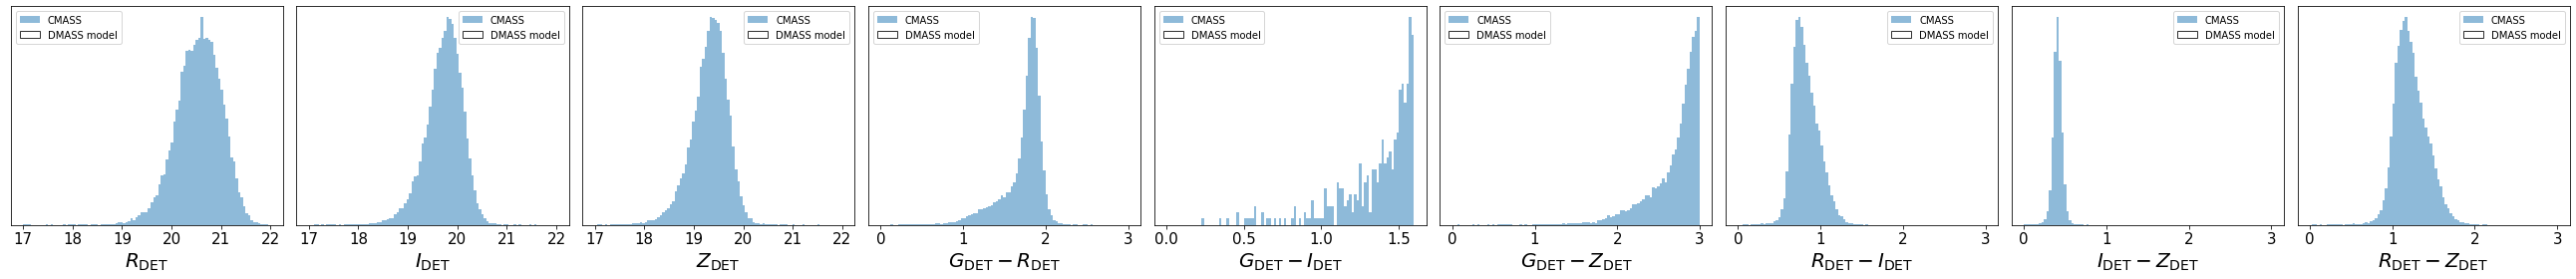

In [54]:
doVisualization_1d( data=[X_cmass_true, X_sample_dmass], 
                   labels = [r'${R_{\rm DET}}$', r'${I_{\rm DET}}$', r'${Z_{\rm DET}}$', r'$G_{\rm DET}-R_{\rm DET}$', r'$G_{\rm DET}-I_{\rm DET}$', r'$G_{\rm DET}-Z_{\rm DET}$', r'$R_{\rm DET}-I_{\rm DET}$', r'$I_{\rm DET}-Z_{\rm DET}$', r'$R_{\rm DET}-Z_{\rm DET}$'], 
                   ranges = [(17,22),(17,22),(17,22),(0,3),(0.0,1.6),(0,3),(0,3),(0,3),(0,3)], 
                   name = ['CMASS','DMASS model'], 
                   weight = [None,None], 
                   color = ['tab:blue','black'],
                   nbins=100, filename = 'cmass_model.pdf')